In [ ]:
using Pkg
Pkg.activate(".")

In [ ]:
using Revise 
using RxInfer, RxGP
using Random, LinearAlgebra, SpecialFunctions, Plots, StableRNGs
using StatsFuns
using Optim, Flux
using KernelFunctions

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [11]:
function predict_gp(X_test, Xu, Yu, var_Yu,C, kernel)
    Kuu = kron(C,kernelmatrix(kernel,Xu))
    K_test_u =kron(C,kernelmatrix(kernel,X_test,Xu))
    Ktest =kron(C,kernelmatrix(kernel,X_test))

    μ = K_test_u * Yu 
    Σ = Ktest - K_test_u * inv(Kuu + Diagonal(var_Yu)) * K_test_u'
    return μ, Σ
end

function  PredictState(prev_state, qv, qw ,qθ, meta)
    return @call_rule MultiSGP(:out, Marginalisation) (q_in = prev_state, q_v = qv, q_w = qw,q_θ = qθ, meta = meta)
end
function UpdateState(prior_prediction, observation)
    likelihood_update = @call_rule MvNormalMeanCovariance(:μ, Marginalisation) (m_out = PointMass(observation), m_Σ = PointMass(P))
    x = ReactiveMP.prod(GenericProd(), prior_prediction, likelihood_update)
    return x
end

## Prediction
function predict_UT(f, qx,qw, meta)
    qz = ReactiveMP.approximate(meta, f, (qx,))
    prediction_x = @call_rule MvNormalMeanPrecision(:out, Marginalisation) (q_μ = qz, q_Λ = qw)
    return prediction_x
end

predict_UT (generic function with 1 method)

In [12]:
N = 700
max_time = 7
Δt = max_time / (N-1)

function transition_function(x_prev)
    x_1 = x_prev[1] + x_prev[2] * Δt 
    x_2 = x_prev[2] - 9.81 * sin(x_prev[1]) * Δt
    return [x_1, x_2]
end

function generate_data(n,x_init, Q, P;rng = MersenneTwister(124))
    x_prev = x_init  #initial angle and angular velocity
    x = Vector{Vector{Float64}}(undef, n)
    y = Vector{Vector{Float64}}(undef, n)
    for i in 1:n
        x[i] = transition_function(x_prev) + rand(rng, MvNormal(zeros(2),Q))
        y[i] = x[i] + rand(rng, MvNormal(zeros(2),P))
        x_prev = x[i]
    end
    return x, y 
end

generate_data (generic function with 1 method)

In [13]:
qc = 0.01
Q = [qc*Δt^3/3 qc*Δt^2/2;qc*Δt^2/2 qc*Δt]

P = 0.1*diageye(2) 
H = [1,0]
x_init = [1.5, 0.]

x_state, y_observation = generate_data(N,x_init, Q,P);
time_interval = collect(0:Δt:max_time)
;

In [14]:
n_train = 300
true_state_train = x_state[1:n_train]
y_train = y_observation[1:n_train]
true_state_test = x_state[1+n_train:end]
y_test = y_observation[1+n_train:end];

Xu_2_neg1 = reverse(collect(range(-4,0;length=12)));
Xu_2_neg2 = reverse(Xu_2_neg1) .+ 1e-5
Xu_2_pos1 = collect(range(1e-4,4;length=12));
Xu_2_pos2 = reverse(Xu_2_pos1)
Xu_2 = vcat(Xu_2_neg1,Xu_2_neg2,Xu_2_pos1,Xu_2_pos2)

Xu_1 = collect(range(-2,2;length=Int(length(Xu_2)/2)));
Xu_1 = vcat(reverse(Xu_1), Xu_1 .+ 1e-5);

In [15]:
#build model
@model function pendulum_GP(y,dim_v,P,θ)
    v ~ MvNormalMeanCovariance(zeros(dim_v), 50*diageye(dim_v))
    W ~ Wishart(1e2,diageye(2))
    x_prev ~ MvNormalMeanCovariance([1.6,0], 0.1*diageye(2))

    for i=1:length(y)
        x[i] ~ MultiSGP(x_prev,v,W,θ)
        y[i] ~ MvNormalMeanCovariance(x[i], P)
        x_prev = x[i]
    end
end

In [19]:
Xu = [[Xu_1[i],Xu_2[i]] for i=1:length(Xu_1)]

kernel_gp(θ) = StatsFuns.softplus(θ[1]) * with_lengthscale(SEKernel(), StatsFuns.softplus.(θ[2:end]))
θ_init = StatsFuns.invsoftplus.([1.,1.,1.]);
gp_method = srcubature()
gp_cache = GPCache()

dim_v = size(Xu[1],1) * length(Xu)
M = length(Xu)
D = size(x_state[1],1)
Ψ0 = [1.0;;]
Ψ1_trans = kernelmatrix(kernel_gp([1.,1.]),Xu,[[1., 1.]])
Ψ2 = kernelmatrix(kernel_gp([1.,1.]),Xu,[[1., 1.]]) * kernelmatrix(kernel_gp([1.,1.]),[[1., 1.]],Xu)
;

In [17]:
@meta function gpssm_meta(method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel,cache)
    MultiSGP() -> MultiSGPMeta(method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel,cache)
end

gp_constraint = @constraints begin
    q(x,x_prev,v,W) = q(x)q(x_prev)q(v)q(W)
    q(x) = q(x[begin])..q(x[end])
end

gp_initialization = @initialization begin
    q(v) = MvNormalMeanCovariance(zeros(dim_v),50*diageye(dim_v))
    q(x) = MvNormalMeanCovariance(zeros(2), 50diageye(2))
    q(W) = Wishart(1e2,diageye(2))
end
;

In [20]:
niter = 30;
Kuu = kernelmatrix(kernel_gp(θ_init),Xu) + 1e-12*I
Kuu_inverse = cholinv(Kuu)

infer_result_gp = infer(
    model = pendulum_GP(dim_v = dim_v,P = P, θ = θ_init,),
    iterations = niter,
    data = (y = y_train,),
    initialization = gp_initialization,
    meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
    constraints = gp_constraint,
    returnvars = (x = KeepLast(), v = KeepLast(), W = KeepLast(),),
    free_energy = true,
    showprogress = true
) 

Progress: 100%|█████████████████████████████████████████| Time: 0:00:13


Inference results:
  Posteriors       | available for (v, W, x)
  Free Energy:     | Real[3223.2, 2683.95, 1562.16, 1038.27, 905.661, 854.499, 827.18, 809.711, 797.351, 788.175  …  755.646, 754.877, 754.241, 753.704, 753.183, 752.751, 752.422, 752.078, 751.918, 751.745]


In [21]:
qv_gp = infer_result_gp.posteriors[:v]
qx_gp = infer_result_gp.posteriors[:x];
qw_gp = infer_result_gp.posteriors[:W];

## Function is known

In [22]:
@model function VMPsmoothing(y,P)
    W ~ Wishart(1e2, diageye(2))
    x_prev ~ MvNormalMeanCovariance([1.6,0], 0.1*diageye(2))

    for i=1:length(y)
        x[i] ~ MvNormalMeanPrecision(transition_function(x_prev), W)
        y[i] ~ MvNormalMeanCovariance(x[i], P)
        x_prev = x[i]
    end
end

In [23]:
meta_VMPsmoothing = @meta begin
    transition_function() -> UT()
end

ut_constraint = @constraints begin
    q(x,x_prev,W) = q(x)q(x_prev)q(W)
    q(x) = q(x[begin])..q(x[end])
end

ut_initialization = @initialization begin
    q(W) = Wishart(1e2,diageye(2))
    q(x) = MvNormalMeanCovariance(zeros(2), 50*diageye(2))
end

infer_result_VMPsmoothing = infer(
    model = VMPsmoothing(P=P),
    data = (y = y_train,),
    meta = meta_VMPsmoothing,
    iterations = niter,
    constraints = ut_constraint,
    initialization = ut_initialization,
    returnvars = (x = KeepLast(), W = KeepLast(),),
    options = (limit_stack_depth=100,),
    free_energy = true
) 

qx_UT = infer_result_VMPsmoothing.posteriors[:x];
qw_UT = infer_result_VMPsmoothing.posteriors[:W]
;

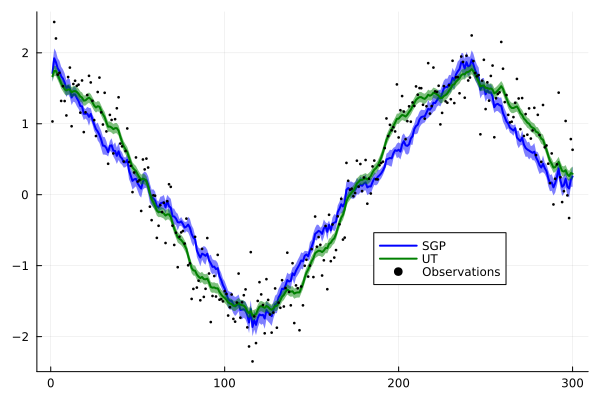

In [26]:
plot(getindex.(mean.(qx_gp),1),ribbon = sqrt.(getindex.(var.(qx_gp),1)),label="SGP",
     lw = 2,
     color=:blue)
plot!(getindex.(mean.(qx_UT),1),ribbon = sqrt.(getindex.(var.(qx_UT),1)),
    label="UT", lw = 2, legend_position=(0.7,0.35),
    color=:green)


scatter!(getindex.(y_train,1), markersize=1.5, label="Observations",color=:black)

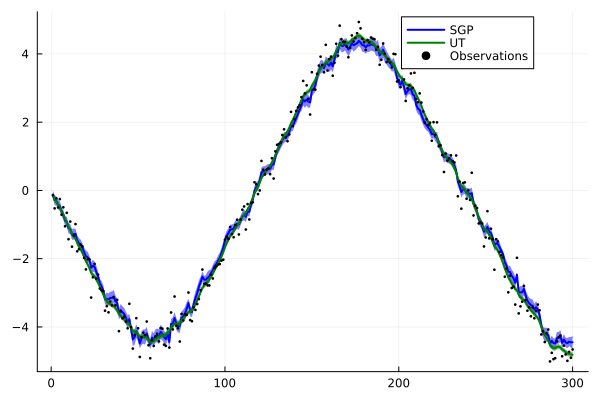

In [27]:
plot(getindex.(mean.(qx_gp),2),ribbon = sqrt.(getindex.(var.(qx_gp),2)),label="SGP", 
        lw = 2, color=:blue)
plot!(getindex.(mean.(qx_UT),2),ribbon = sqrt.(getindex.(var.(qx_UT),2)),label="UT", 
                lw = 2, legend_position=(0.75,0.95), color=:green)
scatter!(getindex.(y_train,2), markersize=1.5, label="Observations", color=:black, alpha=1)

In [30]:
prev_state = qx_gp[end]
predicted_state = []
for i=1:length(y_test)
    prediction = PredictState(prev_state,qv_gp,qw_gp,PointMass(θ_init), MultiSGPMeta(srcubature(),Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,GPCache()))
    push!(predicted_state,prediction)
    prev_state = UpdateState(prediction, y_test[i])
end

;

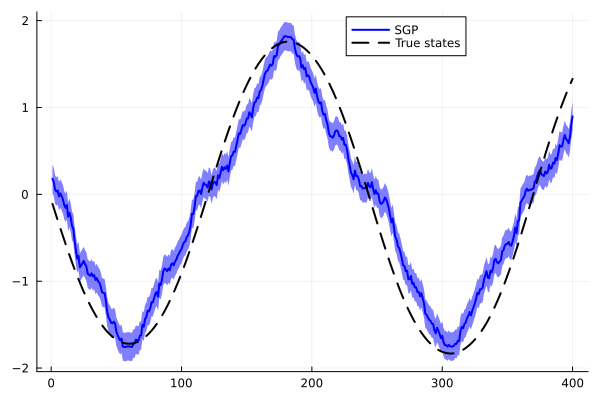

In [32]:
plot(getindex.(mean.(predicted_state),1),ribbon = sqrt.(getindex.(var.(predicted_state),1)) ,
        label="SGP",lw=2, color=:blue,legend_position=(0.65,0.95))

plot!(getindex.(true_state_test,1),label="True states", ls=:dash,lw=2, color=:black)

## Hyperparameters Optimization

In [50]:
function my_free_energy(θ)
    Kuu = kernelmatrix(kernel_gp(θ),Xu) + 1e-12*I
    Kuu_inverse = cholinv(Kuu)
    infer_result_gp = infer(
        model = pendulum_GP(dim_v = dim_v,P = P, θ = θ,),
        iterations = 10,
        data = (y = y_train,),
        initialization = gp_initialization,
        meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
        constraints = gp_constraint,
        returnvars = (x_prev = KeepLast(),x = KeepLast(), v = KeepLast(), W = KeepLast()),
        free_energy = true,
    ) 
    
    return infer_result_gp.free_energy[end], infer_result_gp.posteriors[:x_prev], 
            infer_result_gp.posteriors[:x], infer_result_gp.posteriors[:v], infer_result_gp.posteriors[:W]
end

function PerformInference(θ; epochs)
    FE_value = []
    θ_optimal = θ
    grad = similar(θ)
    optimizer = Flux.AdaMax()
    state = Flux.setup(optimizer, θ_optimal)
    @inbounds for epoch=1:epochs
            #step 1: Perform inference for v, w 
            fe, qx_prev, qx, qv, qW = my_free_energy(θ_optimal)
            #step 2: optimize the hyperparameters 
            gp_qy = mean.(qx) #for output of gp node
            gp_qx = vcat([qx_prev,qx[1:end-1]]...) #for input of gp node
            μ_v, Σ_v = mean_cov(qv)
            Rv = Σ_v + μ_v * μ_v' 
            W_bar = mean(qW)
            sumRv_Wbar = sum(create_blockmatrix(Rv,D,M) .* W_bar);
            for k=1:100
                grad_llh_multi!(grad,θ_optimal; y_data=gp_qy,
                                                qx = gp_qx,
                                                sumRv_Wbar = sumRv_Wbar,
                                                v = μ_v,
                                                W = W_bar,
                                                tr_W = tr(W_bar),
                                                kernel=kernel_gp,
                                                Xu=Xu,
                                                method=gp_method)
                Flux.update!(state,θ_optimal,grad)
            end
            append!(FE_value,fe)
    end
    return FE_value, θ_optimal
end

PerformInference (generic function with 1 method)

In [52]:
@time FE_value, θ_optimal = PerformInference(θ_init;epochs=100);

1097.881132 seconds (10.11 G allocations: 3.757 TiB, 39.30% gc time, 0.00% compilation time)


In [53]:
println("Optimal hyperparameters: ", StatsFuns.softplus.(θ_optimal))

Optimal hyperparameters: [0.5632563762645771, 2.2966481441162716, 4.574702652116561]


In [54]:
niter = 30;
Kuu = kernelmatrix(kernel_gp(θ_optimal),Xu) + 1e-12*I
Kuu_inverse = cholinv(Kuu)

infer_result_gp = infer(
    model = pendulum_GP(dim_v = dim_v,P = P, θ = θ_optimal,),
    iterations = niter,
    data = (y = y_train,),
    initialization = gp_initialization,
    meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
    constraints = gp_constraint,
    returnvars = (x = KeepLast(), v = KeepLast(), W = KeepLast(),),
    free_energy = true,
    showprogress = true
) 

Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


Inference results:
  Posteriors       | available for (v, W, x)
  Free Energy:     | Real[2989.69, 2217.01, 870.818, 602.802, 510.812, 464.381, 436.375, 417.947, 405.664, 397.147  …  378.71, 378.433, 378.224, 378.467, 378.456, 378.468, 378.387, 378.211, 378.352, 378.298]


In [55]:
qv_gp = infer_result_gp.posteriors[:v]
qx_gp = infer_result_gp.posteriors[:x];
qw_gp = infer_result_gp.posteriors[:W];

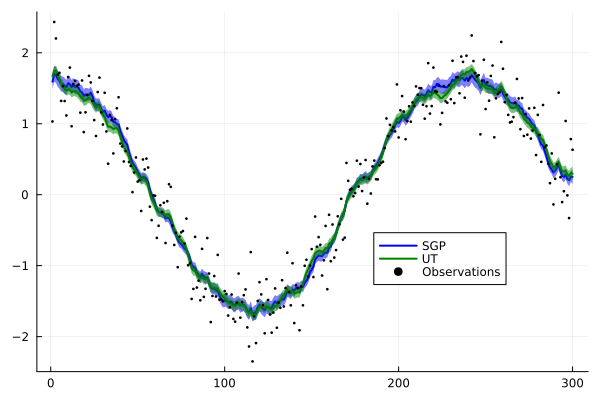

In [56]:
plot(getindex.(mean.(qx_gp),1),ribbon = sqrt.(getindex.(var.(qx_gp),1)),label="SGP",
     lw = 2,
     color=:blue)
plot!(getindex.(mean.(qx_UT),1),ribbon = sqrt.(getindex.(var.(qx_UT),1)),
    label="UT", lw = 2, legend_position=(0.7,0.35),
    color=:green)


scatter!(getindex.(y_train,1), markersize=1.5, label="Observations",color=:black)

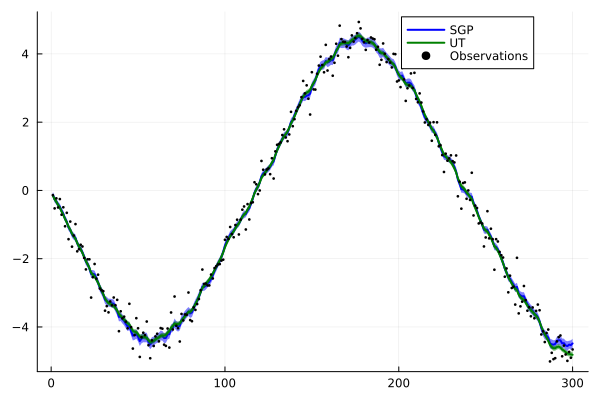

In [57]:
plot(getindex.(mean.(qx_gp),2),ribbon = sqrt.(getindex.(var.(qx_gp),2)),label="SGP", 
        lw = 2, color=:blue)
plot!(getindex.(mean.(qx_UT),2),ribbon = sqrt.(getindex.(var.(qx_UT),2)),label="UT", 
                lw = 2, legend_position=(0.75,0.95), color=:green)
scatter!(getindex.(y_train,2), markersize=1.5, label="Observations", color=:black, alpha=1)

In [58]:
prev_state = qx_gp[end]
predicted_state = []
for i=1:length(y_test)
    prediction = PredictState(prev_state,qv_gp,qw_gp,PointMass(θ_init), MultiSGPMeta(srcubature(),Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,GPCache()))
    push!(predicted_state,prediction)
    prev_state = UpdateState(prediction, y_test[i])
end

;

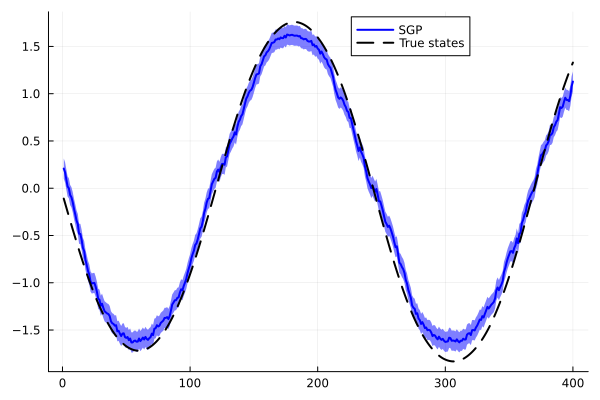

In [59]:
plot(getindex.(mean.(predicted_state),1),ribbon = sqrt.(getindex.(var.(predicted_state),1)) ,
        label="SGP",lw=2, color=:blue,legend_position=(0.65,0.95))

plot!(getindex.(true_state_test,1),label="True states", ls=:dash,lw=2, color=:black)